# 04 - BERT Model za Sentiment Analizu

**Cilj**: Fine-tune BERT model za klasifikaciju sentimenta Bitcoin tweetova

**Hardware**: NVIDIA RTX 4060 (8GB VRAM - perfektno za BERT!)

**Koraci**:
1. Setup i provera GPU
2. Učitavanje preprocessed podataka
3. BERT tokenizacija
4. Kreiranje PyTorch Dataset-a
5. Model setup (pretrained BERT)
6. Training loop sa GPU optimizacijom
7. Evaluacija i poređenje
8. Čuvanje modela

**Očekivano vreme treniranja**: 10-20 minuta (sa RTX 4060)

## 1. Setup - Import Biblioteka

In [1]:
# Osnovne biblioteke
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# Transformers (Hugging Face)
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)

# Sklearn
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Dodaj src folder u path
import sys
sys.path.append('../src')
from evaluation import evaluate_model, print_evaluation_report, plot_confusion_matrix

print("✅ Biblioteke učitane uspešno!")

✅ Biblioteke učitane uspešno!


## 2. Provera GPU - NVIDIA RTX 4060

In [3]:
# Proveri CUDA dostupnost
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("="*60)
print("GPU INFORMACIJE")
print("="*60)
print(f"PyTorch verzija: {torch.__version__}")
print(f"CUDA dostupan: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA verzija: {torch.version.cuda}")
    print(f"Broj GPU-a: {torch.cuda.device_count()}")
    print(f"Ukupna memorija: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    print(f"\n🚀 Koristim: {device}")
else:
    print("⚠️  CUDA nije dostupan - koristim CPU")
    print("   Treniranje će biti JAKO SPORO!")
    print("   Preporučujem: Google Colab (besplatan GPU)")
    
print("="*60)

GPU INFORMACIJE
PyTorch verzija: 2.7.1+cu118
CUDA dostupan: True
GPU: NVIDIA GeForce RTX 4060
CUDA verzija: 11.8
Broj GPU-a: 1
Ukupna memorija: 8.00 GB

🚀 Koristim: cuda


## 3. Učitavanje Preprocessed Podataka

Učitavamo podatke iz Notebook 02 (preprocessing)

In [4]:
# Učitaj train i test podatke
print("Učitavanje podataka...")

train_df = pd.read_csv('../data/processed/train_data.csv')
test_df = pd.read_csv('../data/processed/test_data.csv')

print(f"\n✅ Podaci učitani:")
print(f"   Train set: {len(train_df):,} primera")
print(f"   Test set:  {len(test_df):,} primera")

# Prikaz prvih redova
print("\n📊 Primer podataka:")
display(train_df.head())

# Provera kolona
print("\n📋 Kolone:")
print(train_df.columns.tolist())

Učitavanje podataka...

✅ Podaci učitani:
   Train set: 1,006 primera
   Test set:  252 primera

📊 Primer podataka:


,text,sentiment
0,current block height,neutral
1,active bitcoin address million,neutral
2,bitcoin trading volume today,neutral
3,bitcoin hashrate ehs currently,neutral
4,bitcoin changing life around world,positive



📋 Kolone:
['text', 'sentiment']



📊 Distribucija sentimenta:

Train set:
sentiment
neutral     853
positive    104
negative     49
Name: count, dtype: int64

Procenti:
sentiment
neutral     84.791252
positive    10.337972
negative     4.870775
Name: proportion, dtype: float64

Test set:
sentiment
neutral     214
positive     26
negative     12
Name: count, dtype: int64

Procenti:
sentiment
neutral     84.920635
positive    10.317460
negative     4.761905
Name: proportion, dtype: float64


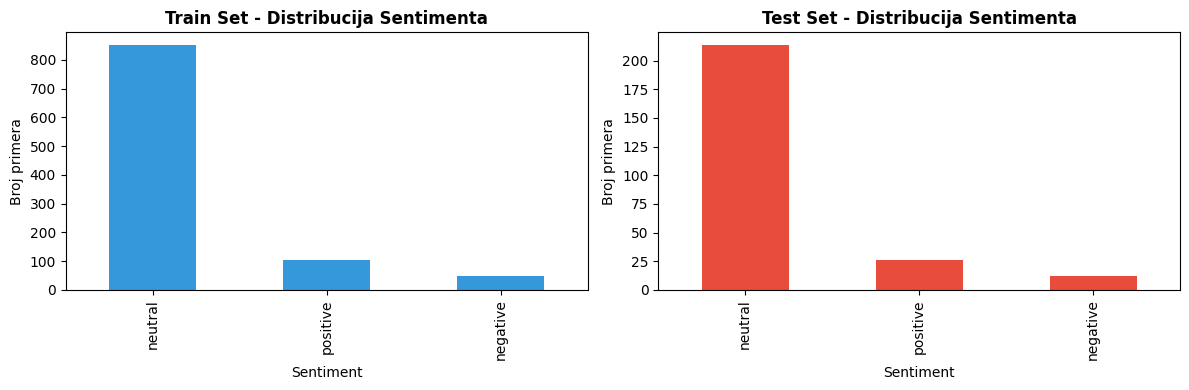

In [5]:
# Provera distribucije sentimenta
print("\n📊 Distribucija sentimenta:")
print("\nTrain set:")
print(train_df['sentiment'].value_counts())
print(f"\nProcenti:")
print(train_df['sentiment'].value_counts(normalize=True) * 100)

print("\nTest set:")
print(test_df['sentiment'].value_counts())
print(f"\nProcenti:")
print(test_df['sentiment'].value_counts(normalize=True) * 100)

# Vizualizacija
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_df['sentiment'].value_counts().plot(kind='bar', ax=axes[0], color='#3498db')
axes[0].set_title('Train Set - Distribucija Sentimenta', fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Broj primera')

test_df['sentiment'].value_counts().plot(kind='bar', ax=axes[1], color='#e74c3c')
axes[1].set_title('Test Set - Distribucija Sentimenta', fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Broj primera')

plt.tight_layout()
plt.show()

## 4. BERT Tokenizacija

BERT koristi specijalni WordPiece tokenizer

In [6]:
# Učitaj BERT tokenizer
print("Učitavanje BERT tokenizer-a...")

MODEL_NAME = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

print(f"✅ Tokenizer učitan: {MODEL_NAME}")
print(f"   Vocabulary size: {tokenizer.vocab_size:,}")

# Test tokenizacije
test_text = "Bitcoin is going to the moon! 🚀"
print(f"\n📝 Test primer:")
print(f"   Original: {test_text}")

# Tokenizuj
encoded = tokenizer.encode_plus(
    test_text,
    add_special_tokens=True,
    max_length=128,
    padding='max_length',
    truncation=True,
    return_attention_mask=True,
    return_tensors='pt'
)

print(f"\n   Tokens: {tokenizer.convert_ids_to_tokens(encoded['input_ids'][0][:20])}")
print(f"   Input IDs shape: {encoded['input_ids'].shape}")
print(f"   Attention mask shape: {encoded['attention_mask'].shape}")

Učitavanje BERT tokenizer-a...
✅ Tokenizer učitan: bert-base-uncased
   Vocabulary size: 30,522

📝 Test primer:
   Original: Bitcoin is going to the moon! 🚀

   Tokens: ['[CLS]', 'bit', '##co', '##in', 'is', 'going', 'to', 'the', 'moon', '!', '[UNK]', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
   Input IDs shape: torch.Size([1, 128])
   Attention mask shape: torch.Size([1, 128])


### Analiza Dužine Tekstova

Analiza dužina tekstova...

📊 Statistika dužina tekstova (broj tokena):
   Mean: 8.7
   Median: 9.0
   Max: 15
   95th percentile: 12.0


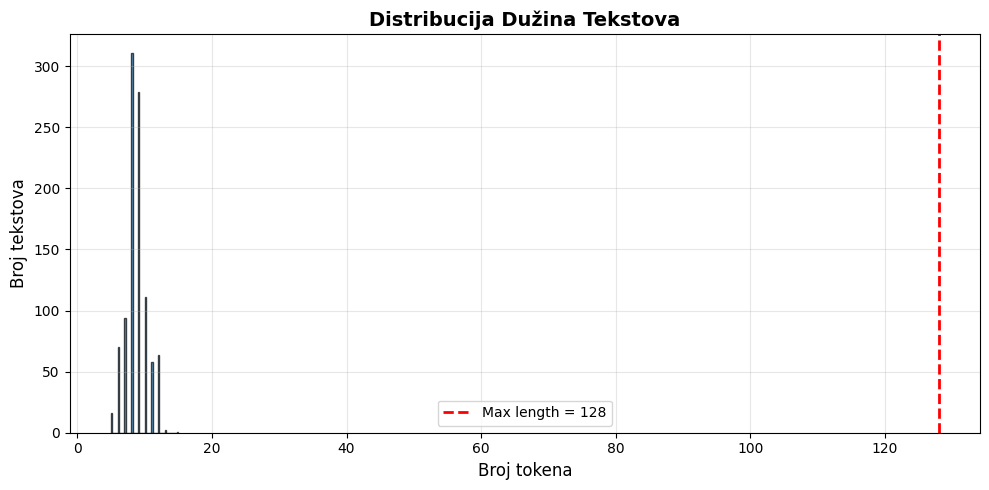


⚠️  Tekstova duže od 128 tokena: 0 (0.00%)
   (Ovi tekstovi će biti skraćeni na 128 tokena)


In [9]:
# Proveri distribuciju dužina tekstova
def get_text_length(text):
    return len(tokenizer.encode(text, add_special_tokens=True))

print("Analiza dužina tekstova...")
train_lengths = train_df['text'].apply(get_text_length)

print("\n📊 Statistika dužina tekstova (broj tokena):")
print(f"   Mean: {train_lengths.mean():.1f}")
print(f"   Median: {train_lengths.median():.1f}")
print(f"   Max: {train_lengths.max()}")
print(f"   95th percentile: {train_lengths.quantile(0.95):.1f}")

# Grafik
plt.figure(figsize=(10, 5))
plt.hist(train_lengths, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(128, color='red', linestyle='--', linewidth=2, label='Max length = 128')
plt.xlabel('Broj tokena', fontsize=12)
plt.ylabel('Broj tekstova', fontsize=12)
plt.title('Distribucija Dužina Tekstova', fontweight='bold', fontsize=14)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Procena procenat tekstova koji se seče
truncated = (train_lengths > 128).sum()
print(f"\n⚠️  Tekstova duže od 128 tokena: {truncated:,} ({truncated/len(train_lengths)*100:.2f}%)")
print("   (Ovi tekstovi će biti skraćeni na 128 tokena)")

## 5. Kreiranje PyTorch Dataset Klase

In [10]:
class SentimentDataset(Dataset):
    """
    PyTorch Dataset za sentiment analizu
    """
    
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Tokenizacija
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }


print("✅ SentimentDataset klasa kreirana")

✅ SentimentDataset klasa kreirana


### Kreiranje Dataset-a i DataLoader-a

In [14]:
# Parametri optimizovani za RTX 4060 (8GB VRAM)
MAX_LENGTH = 128
BATCH_SIZE = 16  # Dobar balance za 8GB
# Ako dobiješ "CUDA out of memory" error, smanji na 8

print(f"Kreiranje dataseta...")
print(f"   Max length: {MAX_LENGTH}")
print(f"   Batch size: {BATCH_SIZE}")

# Mapiranje labela (string -> int) da bi torch.tensor mogao da ih koristi
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}

# Kreiraj train dataset (konvertuj string labele u int)
train_labels = train_df['sentiment'].map(label_map).astype(int).values
train_dataset = SentimentDataset(
    texts=train_df['text'].values,
    labels=train_labels,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

# Kreiraj test dataset  (konvertuj string labele u int)
test_labels = test_df['sentiment'].map(label_map).astype(int).values
test_dataset = SentimentDataset(
    texts=test_df['text'].values,
    labels=test_labels,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

# Kreiraj DataLoader-e
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,  # Na Windows stavi 0, na Linux može 2-4
    pin_memory=True  # Brže prebacivanje na GPU
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"\n✅ Dataset-i kreirani:")
print(f"   Train batches: {len(train_loader):,}")
print(f"   Test batches: {len(test_loader):,}")
print(f"   Train samples: {len(train_dataset):,}")
print(f"   Test samples: {len(test_dataset):,}")

# Test učitavanja jednog batch-a
print(f"\n📦 Test batch:")
sample_batch = next(iter(train_loader))
print(f"   Input IDs shape: {sample_batch['input_ids'].shape}")
print(f"   Attention mask shape: {sample_batch['attention_mask'].shape}")
print(f"   Labels shape: {sample_batch['labels'].shape}")

Kreiranje dataseta...
   Max length: 128
   Batch size: 16

✅ Dataset-i kreirani:
   Train batches: 63
   Test batches: 16
   Train samples: 1,006
   Test samples: 252

📦 Test batch:
   Input IDs shape: torch.Size([16, 128])
   Attention mask shape: torch.Size([16, 128])
   Labels shape: torch.Size([16])


## 6. Model Setup - BERT for Sequence Classification

In [15]:
# Broj klasa (sentiment: 0=negative, 1=neutral, 2=positive)
NUM_CLASSES = 3

print(f"Učitavanje BERT modela...")
print(f"   Model: {MODEL_NAME}")
print(f"   Broj klasa: {NUM_CLASSES}")

# Učitaj pretrained BERT model
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    output_attentions=False,
    output_hidden_states=False
)

# Prebaci model na GPU
model = model.to(device)

print(f"\n✅ Model učitan i prebačen na {device}")

# Broj parametara
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n📊 Model statistike:")
print(f"   Ukupno parametara: {total_params:,}")
print(f"   Trainable parametara: {trainable_params:,}")
print(f"   Veličina modela: ~{total_params * 4 / 1024**2:.1f} MB")

Učitavanje BERT modela...
   Model: bert-base-uncased
   Broj klasa: 3


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



✅ Model učitan i prebačen na cuda

📊 Model statistike:
   Ukupno parametara: 109,484,547
   Trainable parametara: 109,484,547
   Veličina modela: ~417.7 MB


### Optimizer i Learning Rate Scheduler

In [16]:
# Hiperparametri
EPOCHS = 3  # 3-4 je obično dovoljno za fine-tuning
LEARNING_RATE = 2e-5  # Standard za BERT fine-tuning
WARMUP_STEPS = 0  # Broj warmup koraka (0 = bez warmup-a)

print(f"Kreiranje optimizer-a...")
print(f"   Epochs: {EPOCHS}")
print(f"   Learning rate: {LEARNING_RATE}")

# AdamW optimizer (preporučen za transformers)
optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    eps=1e-8
)

# Learning rate scheduler (opciono)
total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps
)

print(f"\n✅ Optimizer kreiran")
print(f"   Total training steps: {total_steps:,}")
print(f"   Steps per epoch: {len(train_loader):,}")

Kreiranje optimizer-a...
   Epochs: 3
   Learning rate: 2e-05

✅ Optimizer kreiran
   Total training steps: 189
   Steps per epoch: 63


## 7. Training Loop - Fine-tuning BERT

In [17]:
def train_epoch(model, data_loader, optimizer, device, scheduler):
    """
    Treniranje jedne epohe
    """
    model.train()
    
    losses = []
    correct_predictions = 0
    total_predictions = 0
    
    progress_bar = tqdm(data_loader, desc='Training')
    
    for batch in progress_bar:
        # Prebaci batch na GPU
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        logits = outputs.logits
        
        # Predviđanja
        _, preds = torch.max(logits, dim=1)
        correct_predictions += torch.sum(preds == labels)
        total_predictions += labels.size(0)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping (sprečava exploding gradients)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        scheduler.step()
        
        losses.append(loss.item())
        
        # Ažuriraj progress bar
        progress_bar.set_postfix({
            'loss': f"{np.mean(losses[-10:]):.4f}",
            'acc': f"{(correct_predictions.double() / total_predictions).item():.4f}"
        })
    
    return {
        'loss': np.mean(losses),
        'accuracy': (correct_predictions.double() / total_predictions).item()
    }


def eval_model(model, data_loader, device):
    """
    Evaluacija modela na validation/test setu
    """
    model.eval()
    
    losses = []
    correct_predictions = 0
    total_predictions = 0
    
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(data_loader, desc='Evaluating'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            
            loss = outputs.loss
            logits = outputs.logits
            
            _, preds = torch.max(logits, dim=1)
            
            correct_predictions += torch.sum(preds == labels)
            total_predictions += labels.size(0)
            
            losses.append(loss.item())
            
            all_predictions.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return {
        'loss': np.mean(losses),
        'accuracy': (correct_predictions.double() / total_predictions).item(),
        'predictions': np.array(all_predictions),
        'labels': np.array(all_labels)
    }


print("✅ Training funkcije kreirane")

✅ Training funkcije kreirane


### 🚀 Pokreni Treniranje!

In [18]:
import time

print("="*60)
print("POČETAK TRENIRANJA BERT MODELA")
print("="*60)
print(f"Device: {device}")
print(f"Epochs: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Total steps: {total_steps:,}")
print(f"\nOčekivano vreme: ~{EPOCHS * 5:.0f}-{EPOCHS * 10:.0f} minuta (sa GPU)")
print("="*60 + "\n")

start_time = time.time()

# Čuvaj istoriju
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

# Treniranje kroz epohe
for epoch in range(EPOCHS):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"{'='*60}")
    
    # Training
    train_metrics = train_epoch(model, train_loader, optimizer, device, scheduler)
    print(f"\n📊 Train Loss: {train_metrics['loss']:.4f}")
    print(f"📊 Train Accuracy: {train_metrics['accuracy']:.4f} ({train_metrics['accuracy']*100:.2f}%)")
    
    # Validation/Evaluation na test setu
    val_metrics = eval_model(model, test_loader, device)
    print(f"\n📊 Val Loss: {val_metrics['loss']:.4f}")
    print(f"📊 Val Accuracy: {val_metrics['accuracy']:.4f} ({val_metrics['accuracy']*100:.2f}%)")
    
    # Sačuvaj istoriju
    history['train_loss'].append(train_metrics['loss'])
    history['train_acc'].append(train_metrics['accuracy'])
    history['val_loss'].append(val_metrics['loss'])
    history['val_acc'].append(val_metrics['accuracy'])

end_time = time.time()
training_time = (end_time - start_time) / 60

print(f"\n{'='*60}")
print(f"✅ TRENIRANJE ZAVRŠENO!")
print(f"{'='*60}")
print(f"⏱️  Ukupno vreme: {training_time:.2f} minuta")
print(f"📈 Finalna Train Accuracy: {history['train_acc'][-1]*100:.2f}%")
print(f"📈 Finalna Val Accuracy: {history['val_acc'][-1]*100:.2f}%")
print(f"{'='*60}")

POČETAK TRENIRANJA BERT MODELA
Device: cuda
Epochs: 3
Batch size: 16
Learning rate: 2e-05
Total steps: 189

Očekivano vreme: ~15-30 minuta (sa GPU)


Epoch 1/3


Training:   0%|          | 0/63 [00:00<?, ?it/s]


📊 Train Loss: 0.4465
📊 Train Accuracy: 0.8509 (85.09%)


Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]


📊 Val Loss: 0.1974
📊 Val Accuracy: 0.9325 (93.25%)

Epoch 2/3


...


📊 Val Loss: 0.1300
📊 Val Accuracy: 0.9524 (95.24%)

Epoch 3/3


Training:   0%|          | 0/63 [00:00<?, ?it/s]


📊 Train Loss: 0.0663
📊 Train Accuracy: 0.9781 (97.81%)


Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]


📊 Val Loss: 0.1030
📊 Val Accuracy: 0.9603 (96.03%)

✅ TRENIRANJE ZAVRŠENO!
⏱️  Ukupno vreme: 0.67 minuta
📈 Finalna Train Accuracy: 97.81%
📈 Finalna Val Accuracy: 96.03%


### Grafik Training Istorije

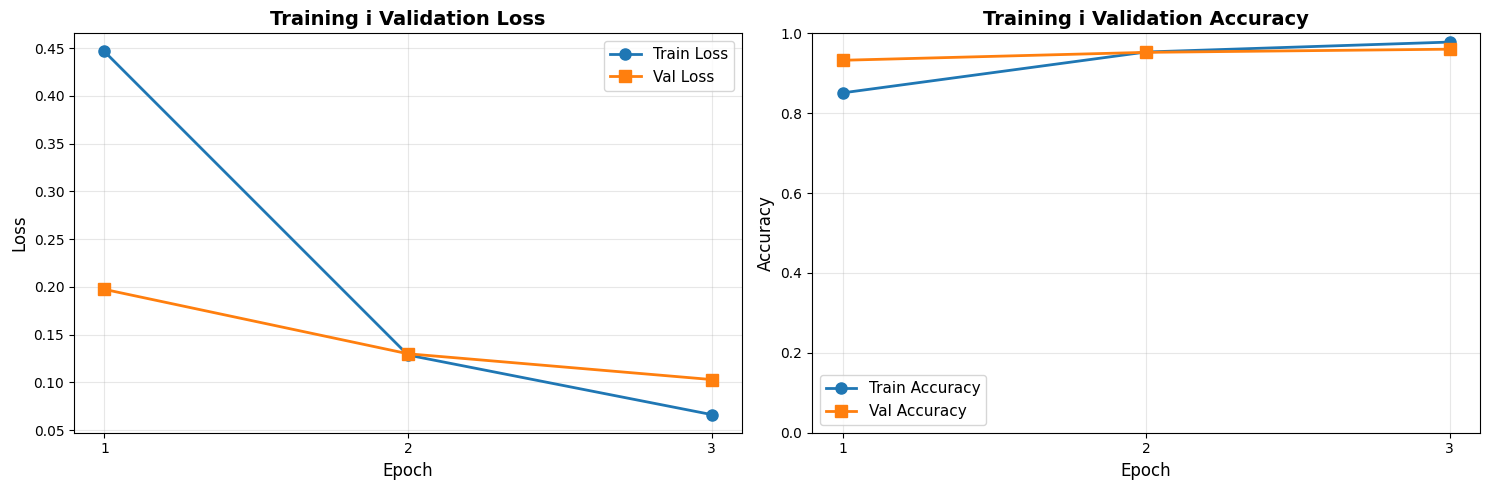

✅ Grafik sačuvan u: results/figures/bert_training_history.png


In [19]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(range(1, EPOCHS+1), history['train_loss'], label='Train Loss', 
             marker='o', linewidth=2, markersize=8)
axes[0].plot(range(1, EPOCHS+1), history['val_loss'], label='Val Loss', 
             marker='s', linewidth=2, markersize=8)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training i Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)
axes[0].set_xticks(range(1, EPOCHS+1))

# Accuracy
axes[1].plot(range(1, EPOCHS+1), history['train_acc'], label='Train Accuracy', 
             marker='o', linewidth=2, markersize=8)
axes[1].plot(range(1, EPOCHS+1), history['val_acc'], label='Val Accuracy', 
             marker='s', linewidth=2, markersize=8)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training i Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)
axes[1].set_ylim([0, 1])
axes[1].set_xticks(range(1, EPOCHS+1))

plt.tight_layout()
plt.savefig('../results/figures/bert_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Grafik sačuvan u: results/figures/bert_training_history.png")

## 8. Finalna Evaluacija na Test Setu

In [20]:
print("\n📊 FINALNA EVALUACIJA NA TEST SETU")
print("="*60)

# Finalna evaluacija
final_results = eval_model(model, test_loader, device)

y_true = final_results['labels']
y_pred = final_results['predictions']

# Detaljne metrike
bert_metrics = print_evaluation_report(y_true, y_pred, "BERT Model")


📊 FINALNA EVALUACIJA NA TEST SETU


Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]


EVALUACIJA MODELA: BERT Model
Accuracy:  0.9603 (96.03%)
Precision: 0.9575
Recall:    0.9603
F1-Score:  0.9586

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.58      0.64        12
           1       0.99      1.00      0.99       214
           2       0.84      0.81      0.82        26

    accuracy                           0.96       252
   macro avg       0.84      0.80      0.82       252
weighted avg       0.96      0.96      0.96       252




### Confusion Matrix

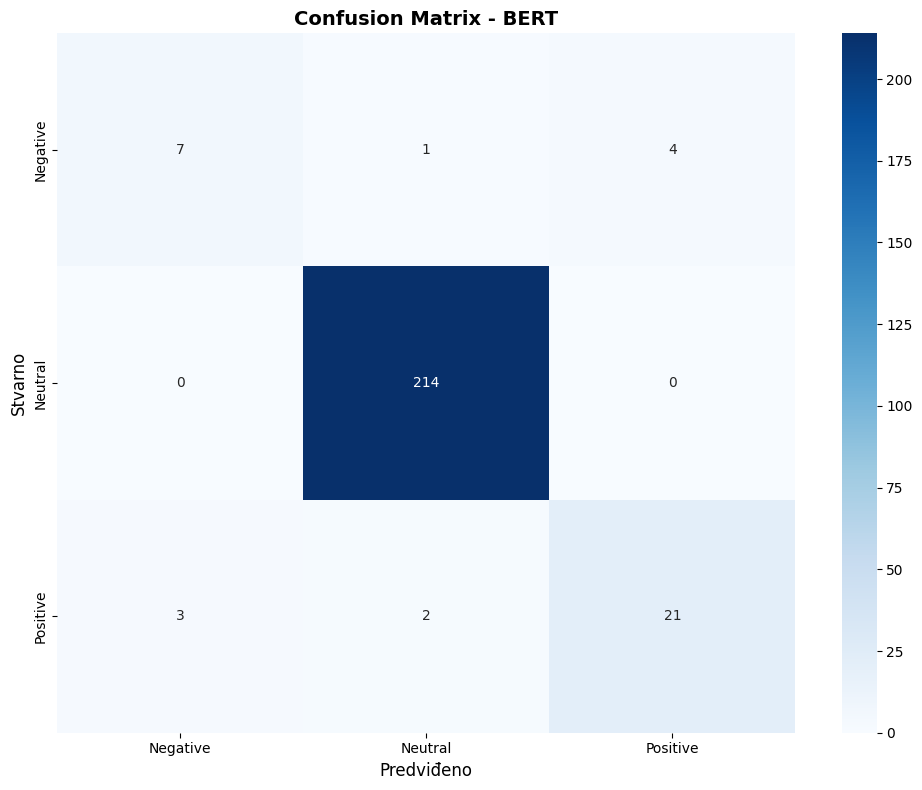

✅ Confusion matrix sačuvan u: results/figures/bert_confusion_matrix.png


In [21]:
# Plot confusion matrix
fig = plot_confusion_matrix(
    y_true, 
    y_pred, 
    labels=['Negative', 'Neutral', 'Positive'],
    model_name='BERT'
)
plt.savefig('../results/figures/bert_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Confusion matrix sačuvan u: results/figures/bert_confusion_matrix.png")

## 9. Poređenje sa Baseline Modelima

In [22]:
import json
import os

# Učitaj baseline rezultate iz Notebook 03
try:
    with open('../results/baseline_results.json', 'r') as f:
        baseline_results = json.load(f)
    
    # Dodaj BERT rezultate
    all_results = baseline_results + [bert_metrics]
    
    print("\n📊 POREĐENJE SVIH MODELA")
    print("="*80)
    
    results_df = pd.DataFrame(all_results)
    results_df = results_df[['model_name', 'accuracy', 'precision', 'recall', 'f1_score']]
    
    # Formatiraj za prikaz
    display_df = results_df.copy()
    for col in ['accuracy', 'precision', 'recall', 'f1_score']:
        display_df[col] = display_df[col].apply(lambda x: f"{x:.4f}")
    
    display(display_df)
    
    # Sačuvaj ažurirane rezultate
    os.makedirs('../results', exist_ok=True)
    with open('../results/all_models_results.json', 'w') as f:
        json.dump(all_results, f, indent=2)
    
    print("\n✅ Rezultati sačuvani u: results/all_models_results.json")
    
except FileNotFoundError:
    print("⚠️  baseline_results.json nije pronađen")
    print("   Prvo pokreni Notebook 03 (baseline models)")
    
    # Sačuvaj samo BERT rezultate
    os.makedirs('../results', exist_ok=True)
    with open('../results/bert_results.json', 'w') as f:
        json.dump([bert_metrics], f, indent=2)
    
    print("\n✅ BERT rezultati sačuvani u: results/bert_results.json")
    all_results = None

⚠️  baseline_results.json nije pronađen
   Prvo pokreni Notebook 03 (baseline models)

✅ BERT rezultati sačuvani u: results/bert_results.json


### Vizualno Poređenje Modela

In [23]:
# Ako postoje baseline rezultati, plotuj poređenje
if all_results is not None:
    try:
        from evaluation import plot_metrics_comparison
        
        fig = plot_metrics_comparison(all_results)
        plt.savefig('../results/figures/models_comparison.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("✅ Grafik sačuvan u: results/figures/models_comparison.png")
        
        # Tabela poboljšanja
        print("\n📈 POBOLJŠANJE U ODNOSU NA BASELINE MODELE")
        print("="*60)
        
        bert_acc = bert_metrics['accuracy']
        
        for result in baseline_results:
            model_name = result['model_name']
            baseline_acc = result['accuracy']
            improvement = (bert_acc - baseline_acc) * 100
            
            print(f"{model_name}:")
            print(f"   Baseline: {baseline_acc*100:.2f}%")
            print(f"   BERT: {bert_acc*100:.2f}%")
            print(f"   Poboljšanje: {improvement:+.2f}%\n")
        
    except Exception as e:
        print(f"⚠️  Greška pri pravljenju grafika: {e}")
else:
    print("⚠️  Baseline rezultati nisu dostupni za poređenje")

⚠️  Baseline rezultati nisu dostupni za poređenje


## 10. Čuvanje BERT Modela

In [24]:
# Kreiraj folder za model
model_save_path = '../results/models/bert_sentiment'
os.makedirs(model_save_path, exist_ok=True)

print("Čuvanje BERT modela...")

# Sačuvaj model
model.save_pretrained(model_save_path)
tokenizer.save_pretrained(model_save_path)

print(f"\n✅ Model sačuvan u: {model_save_path}")
print("\nSačuvani fajlovi:")
for file in os.listdir(model_save_path):
    file_path = os.path.join(model_save_path, file)
    size = os.path.getsize(file_path) / (1024**2)  # MB
    print(f"   - {file} ({size:.1f} MB)")

# Sačuvaj training config
config = {
    'model_name': MODEL_NAME,
    'num_classes': NUM_CLASSES,
    'max_length': MAX_LENGTH,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'epochs': EPOCHS,
    'training_time_minutes': training_time,
    'final_train_accuracy': float(history['train_acc'][-1]),
    'final_val_accuracy': float(history['val_acc'][-1]),
    'test_accuracy': float(bert_metrics['accuracy']),
    'test_f1_score': float(bert_metrics['f1_score']),
    'device': str(device)
}

with open(os.path.join(model_save_path, 'training_config.json'), 'w') as f:
    json.dump(config, f, indent=2)

print("\n✅ Training config sačuvan: training_config.json")

Čuvanje BERT modela...

✅ Model sačuvan u: ../results/models/bert_sentiment

Sačuvani fajlovi:
   - config.json (0.0 MB)
   - model.safetensors (417.7 MB)
   - special_tokens_map.json (0.0 MB)
   - tokenizer_config.json (0.0 MB)
   - vocab.txt (0.2 MB)

✅ Training config sačuvan: training_config.json


## 11. Test Inference - Predict na Novim Podacima

In [25]:
def predict_sentiment(text, model, tokenizer, device):
    """
    Predviđanje sentimenta za novi tekst
    """
    model.eval()
    
    # Tokenizuj
    encoding = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    # Predviđanje
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)
        prediction = torch.argmax(probs, dim=1)
    
    sentiment_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    
    return {
        'text': text,
        'sentiment': sentiment_map[prediction.item()],
        'confidence': probs[0][prediction].item(),
        'probabilities': {
            'negative': probs[0][0].item(),
            'neutral': probs[0][1].item(),
            'positive': probs[0][2].item()
        }
    }


# Test primeri
test_texts = [
    "Bitcoin is going to the moon! 🚀",
    "I just lost all my money on crypto...",
    "Bitcoin price is stable today",
    "This is the best investment ever!",
    "I'm worried about the market crash",
    "HODL! Bitcoin will reach 100k soon!",
    "Crypto is a scam, stay away",
    "Just bought more BTC, feeling good"
]

print("\n" + "="*80)
print("TEST PREDVIĐANJA NA NOVIM TWEETOVIMA")
print("="*80)

for i, text in enumerate(test_texts, 1):
    result = predict_sentiment(text, model, tokenizer, device)
    
    print(f"\n{i}. 📝 Tweet: \"{result['text']}\"")
    print(f"   Sentiment: {result['sentiment']} (confidence: {result['confidence']*100:.1f}%)")
    print(f"   Probabilities:")
    print(f"      - Negative: {result['probabilities']['negative']*100:.1f}%")
    print(f"      - Neutral:  {result['probabilities']['neutral']*100:.1f}%")
    print(f"      - Positive: {result['probabilities']['positive']*100:.1f}%")

print("\n" + "="*80)


TEST PREDVIĐANJA NA NOVIM TWEETOVIMA

1. 📝 Tweet: "Bitcoin is going to the moon! 🚀"
   Sentiment: Positive (confidence: 89.4%)
   Probabilities:
      - Negative: 9.0%
      - Neutral:  1.6%
      - Positive: 89.4%

2. 📝 Tweet: "I just lost all my money on crypto..."
   Sentiment: Positive (confidence: 59.3%)
   Probabilities:
      - Negative: 28.0%
      - Neutral:  12.6%
      - Positive: 59.3%

3. 📝 Tweet: "Bitcoin price is stable today"
   Sentiment: Neutral (confidence: 99.3%)
   Probabilities:
      - Negative: 0.4%
      - Neutral:  99.3%
      - Positive: 0.3%

4. 📝 Tweet: "This is the best investment ever!"
   Sentiment: Positive (confidence: 61.3%)
   Probabilities:
      - Negative: 22.1%
      - Neutral:  16.7%
      - Positive: 61.3%

5. 📝 Tweet: "I'm worried about the market crash"
   Sentiment: Positive (confidence: 46.8%)
   Probabilities:
      - Negative: 30.7%
      - Neutral:  22.6%
      - Positive: 46.8%

6. 📝 Tweet: "HODL! Bitcoin will reach 100k soon!"
   Sent

## 12. Sažetak i Zaključci

In [26]:
print("\n" + "="*80)
print("📊 FINALNI REZULTATI - BERT MODEL")
print("="*80)

print(f"\n🎯 Model: {MODEL_NAME}")
print(f"💻 Device: {device}")
print(f"⏱️  Training vreme: {training_time:.2f} minuta")
print(f"📈 Broj epoha: {EPOCHS}")
print(f"💾 Batch size: {BATCH_SIZE}")
print(f"🎓 Learning rate: {LEARNING_RATE}")

print(f"\n📊 PERFORMANSE NA TEST SETU:")
print(f"   Accuracy:  {bert_metrics['accuracy']*100:.2f}%")
print(f"   Precision: {bert_metrics['precision']:.4f}")
print(f"   Recall:    {bert_metrics['recall']:.4f}")
print(f"   F1-Score:  {bert_metrics['f1_score']:.4f}")

print(f"\n💾 SAČUVANI FAJLOVI:")
print(f"   - Model: {model_save_path}")
print(f"   - Confusion matrix: results/figures/bert_confusion_matrix.png")
print(f"   - Training history: results/figures/bert_training_history.png")
print(f"   - Rezultati: results/bert_results.json ili results/all_models_results.json")

if all_results is not None:
    print(f"\n📈 POREĐENJE SA BASELINE MODELIMA:")
    for result in baseline_results:
        improvement = (bert_metrics['accuracy'] - result['accuracy']) * 100
        print(f"   {result['model_name']:15s}: {improvement:+.2f}% poboljšanje")

print("\n" + "="*80)
print("✅ NOTEBOOK 04 ZAVRŠEN!")
print("="*80)

print("\n🔜 SLEDEĆI KORAK:")
print("   Notebook 05: Korelacija Sentiment-a sa Bitcoin Cenom")
print("   - Analiza sentiment skorova kroz vreme")
print("   - Korelacija sa Bitcoin cenom")
print("   - Statistička značajnost")
print("   - Grafikoni i zaključci")
print("\n💡 Za pokretanje Notebook 05:")
print("   jupyter notebook notebooks/05_correlation_analysis.ipynb\n")


📊 FINALNI REZULTATI - BERT MODEL

🎯 Model: bert-base-uncased
💻 Device: cuda
⏱️  Training vreme: 0.67 minuta
📈 Broj epoha: 3
💾 Batch size: 16
🎓 Learning rate: 2e-05

📊 PERFORMANSE NA TEST SETU:
   Accuracy:  96.03%
   Precision: 0.9575
   Recall:    0.9603
   F1-Score:  0.9586

💾 SAČUVANI FAJLOVI:
   - Model: ../results/models/bert_sentiment
   - Confusion matrix: results/figures/bert_confusion_matrix.png
   - Training history: results/figures/bert_training_history.png
   - Rezultati: results/bert_results.json ili results/all_models_results.json

✅ NOTEBOOK 04 ZAVRŠEN!

🔜 SLEDEĆI KORAK:
   Notebook 05: Korelacija Sentiment-a sa Bitcoin Cenom
   - Analiza sentiment skorova kroz vreme
   - Korelacija sa Bitcoin cenom
   - Statistička značajnost
   - Grafikoni i zaključci

💡 Za pokretanje Notebook 05:
   jupyter notebook notebooks/05_correlation_analysis.ipynb

